In [ ]:
# 필요한 라이브러리 설치
# ==============================
# transformers : HuggingFace 모델 사용
# datasets     : 데이터셋 로딩
# torch        : 딥러닝 프레임워크 (PyTorch)
# torchvision  : 이미지 처리 관련
# pillow       : 이미지 열기

!pip install transformers datasets torch torchvision pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 892.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 MB 4.9 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 3.6.0
    Uninstalling triton-3.6.0:
      Successfully uninstalled triton-3.6.0
  Attempting uninstall: nvidia-nvshmem-cu12
    Found existing installation: nvidia-nvshmem-cu12 3.4.5
    Uninstalling nvidia-nvshmem-cu12-3.4.5:
      Successfully uninstalled nvidia-nvshmem-cu12-3.4.5
  Attempting uninstall: torch
    Found existing installation: torch 2.10.0
    Uninstalling torch-2.10.0:
      Successfully uninstalled torch-2.10.0


In [ ]:
# torch 재설치 (충돌 방지 목적)
!pip uninstall torch -y
!pip install torch

Found existing installation: torch 2.9.0
Uninstalling torch-2.9.0:
  Successfully uninstalled torch-2.9.0
  Using cached torch-2.10.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached nvidia_nvshmem_cu12-3.4.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using cached triton-3.6.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
Using cached torch-2.10.0-cp312-cp312-manylinux_2_28_x86_64.whl (915.7 MB)
Using cached nvidia_nvshmem_cu12-3.4.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (139.1 MB)
Using cached triton-3.6.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (188.3 MB)
  Attempting uninstall: triton
    Found existing installation: triton 3.5.0
    Uninstalling triton-3.5.0:
      Successfully uninstalled triton-3.5.0
ERROR: Operation cancelled by user


In [ ]:
# 현재 설치된 패키지 목록 확인
pip list

Package                                  Version
---------------------------------------- -----------------
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.3
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                           

# HuggingFace 토큰 설정

In [ ]:
# Colab 사용자 저장소에서 토큰 불러오기
from google.colab import userdata
token = userdata.get('hf_token')

In [ ]:
# 환경 변수에 토큰 저장 (모델 다운로드 인증용)
import os
os.environ['HUGGINGFACE_TOKEN'] = token

# ViT 모델 및 이미지 로딩

In [ ]:
from PIL import Image
import requests

# COCO 데이터셋에 있는 예시 이미지 URL
url = 'http://images.cocodataset.org/val2017/000000039769.jpg'

# 이미지 다운로드 및 열기
image = Image.open(requests.get(url, stream=True).raw)
image   # 이미지 출력

from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests

PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


ModuleNotFoundError: Could not import module 'ViTImageProcessor'. Are this object's requirements defined correctly?

In [ ]:
# 4. 사전학습 모델 불러오기
# google의 ViT Base 모델 (ImageNet 1000 클래스 분류용)
# ViT(Image Classification용 Vision Transformer) 모델 불러오기
from transformers import ViTImageProcessor, ViTForImageClassification
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits
# model predicts one of the 1000 ImageNet classes
predicted_class_idx = logits.argmax(-1).item()
print("Predicted class:", model.config.id2label[predicted_class_idx])

# 이미지 전처리

In [ ]:
# 모델 입력 형태에 맞게 이미지 변환 (Tensor 형태로 변환)
inputs = processor(images=image, return_tensors="pt")

# 6. 모델 추론 (Inference)

In [ ]:
# 모델에 이미지 입력 → 예측 결과 출력
outputs = model(**inputs)

# 분류 점수 (로짓값)
logits = outputs.logits

# 예측 결과 확인

In [ ]:
# 가장 높은 확률을 가진 클래스 index 선택
predicted_class_idx = logits.argmax(-1).item()

# ImageNet 1000개 클래스 중 예측된 클래스 이름 출력
print("Predicted class:", model.config.id2label[predicted_class_idx])

# 문장 인코딩 예제 (Bag-of-Words, TF-IDF)

In [ ]:
# 예시 문장 리스트 생성
text = ['This is the first document.',
        'This document is the second document.',
        'And this is the third one.',
        'Is this the first document?']
# → 4개의 문장을 벡터화 실습용으로 사용

text = ['This is the first document.',
          'This document is the second document.',
          'And this is the third one.',
          'Is this the first document?']
text

# CountVectorizer (Bag-of-Words)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# 단어 등장 횟수 기반 벡터화 객체 생성
cv = CountVectorizer()

# 단어 사전 생성 + 문장 벡터화 수행
x = cv.fit_transform(text)

# 희소행렬(Sparse Matrix) 형태 출력
x

# 밀집행렬(Dense Matrix)로 변환
x.toarray()

# 단어(feature) 이름과 함께 DataFrame으로 변환
import pandas as pd
x_df = pd.DataFrame(x.toarray(), columns=cv.get_feature_names_out())
x_df.head(10)

# TF-IDF Vectorizer

* TF (Term Frequency) : 단어 빈도
* IDF (Inverse Document Frequency) : 전체 문서에서 희귀한 단어에 가중치 부여

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF 벡터화 객체 생성
tfidf = TfidfVectorizer()

# 학습 + 변환
x3 = tfidf.fit_transform(text)

# 생성된 단어 목록 출력
print(tfidf.get_feature_names_out())

# TF-IDF 값 출력
print(x3.toarray())

# DataFrame으로 변환
x3_df = pd.DataFrame(x3.toarray(), columns=tfidf.get_feature_names_out())
x3_df.head(10)

# 실제 감성분석 데이터 불러오기

In [ ]:
# sent_train.tsv 파일 읽기 (상위 1000개만 사용)
import pandas as pd

sent = pd.read_csv('/content/sent_train.tsv', delimiter='\t').head(1000)

# 데이터 확인
sent.head()            # 상위 5개 확인
sent.shape             # 행, 열 개수
sent.dtypes            # 데이터 타입 확인
sent.isna().sum()      # 결측치 확인
sent.describe()        # 통계 요약
sent.groupby('Sentiment').size()  # 감정 라벨별 개수

<Axes: xlabel='Sentiment', ylabel='count'>

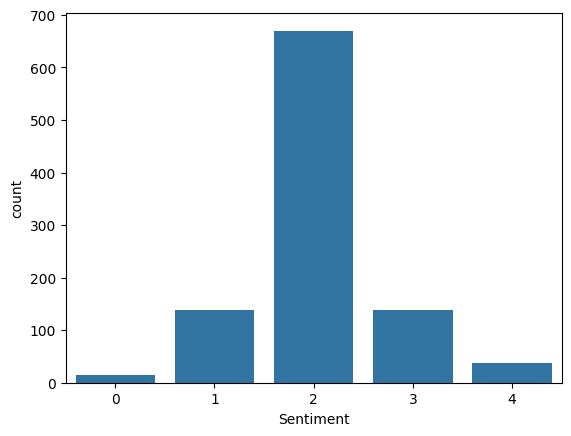

In [ ]:


# Read sent_train.tsv 훈련데이터 읽기 (PhraseId를 인덱스로!)
sent = pd.read_csv('/content/sent_train.tsv', delimiter='\t').head(1000)
# Summarize the data frame. 데이터프레임 요약
# head(), shape, dtypes, isna().sum(), describe(), groupby().size()
sent.head()
sent.shape
sent.dtypes
sent.isna().sum()
sent.describe()
sent.groupby('Sentiment').size()
# Data visualization. 데이터시각화
import seaborn as sns

sns.countplot(x='Sentiment', data=sent)
# Countplot. 감정에 따른 카운트 막대그래프

In [ ]:
# 데이터 시각화
import seaborn as sns

# 감정 분포 시각화 (0~4 감정 클래스)
sns.countplot(x='Sentiment', data=sent)

# 텍스트 전처리 + 벡터화

In [ ]:
from nltk.tokenize import RegexpTokenizer

# 알파벳만 추출하는 토크나이저
token = RegexpTokenizer(r'[a-zA-Z]+')

# CountVectorizer 설정
cv = CountVectorizer(
    lowercase=True,          # 소문자 변환
    stop_words='english',    # 영어 불용어 제거
    ngram_range=(1,1),       # unigram (1-gram)
    tokenizer=token.tokenize # 정규표현식 기반 토큰화
)

# 문장(Phrase) 컬럼 벡터화
text_counts = cv.fit_transform(sent['Phrase'])

# DataFrame 변환
df = pd.DataFrame(text_counts.toarray(), columns=cv.get_feature_names_out())

# 학습/테스트 데이터 분리

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df,
    sent.Sentiment,
    test_size=0.3,
    random_state=1
)

# 👉 70% 학습 / 30% 테스트

# 신경망 모델 구축 (다층 퍼셉트론)

In [ ]:
from keras import Sequential
from keras.layers import Dense

model = Sequential()

# 입력층 → 은닉층 (노드 100개, ReLU)
model.add(Dense(100, input_dim=df.shape[1], activation='relu'))

# 출력층 (감정 5개 클래스 → softmax)
model.add(Dense(5, activation='softmax'))

# 모델 컴파일
model.compile(
    loss='sparse_categorical_crossentropy',  # 다중분류 손실함수
    optimizer='adam',
    metrics=['accuracy']
)

# 모델 학습

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=16
)

# 학습 정확도 시각화

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4650 - loss: 1.5426
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6878 - loss: 1.2089
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6699 - loss: 0.9902
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7160 - loss: 0.8017
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7032 - loss: 0.7732
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7419 - loss: 0.6774
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7931 - loss: 0.5902
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7844 - loss: 0.6004
Epoch 9/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8041 - loss: 0.5105
Epoch 10/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7955 - loss: 0.5274


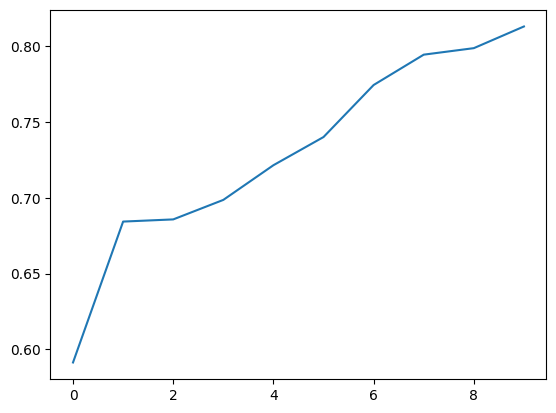

In [ ]:
# 히스토리 그래프
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# 새로운 문장 예측

In [ ]:
# §Prediction with test data. 테스트 데이터로 예측
import numpy as np

# 테스트 문장 생성
test_data = pd.DataFrame({'Phrase': ['hello my name is kim']})

# 동일한 벡터라이저로 변환 (fit 하면 안됨!)
test_data_vec = cv.transform(test_data['Phrase']).toarray()

# 예측 수행
prediction = model.predict(test_data_vec)

# 가장 확률이 높은 클래스 선택
np.argmax(prediction)

# 👉 출력값은 0~4 중 하나 (감정 클래스)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


np.int64(2)